# UAS Eksplorasi dan Visual Data
Alicia Arifin<br>
20214920001<br>
Statistika / Matana University<br>
<br>

Data yang akan digunakan dalam UAS ini adalah data tentang sentimen tentang series Netflix berjudul 'Stranger Things' yang akan memulai season terbarunya tahun depan. Data yang diambil berjumlah 25 sentimen yang berbahasa inggiris. Sentimen yang diambil berdasarkan dari X dengan menggunakan package `tweepy`.  Stranger Things season 1 mulai tayang di netflix pada tahun 2016. Stranger things adalah seri horror-thriller yang dibuat oleh Duffer Brothers. Stranger things season 5 adalah season final dari series stranger things. Stranger things adalah salah satu series terbaik menurut . Netflix mengatakan bahwa season sebelumnya "Stranger Things 4" duduk di ranking no 1 sebagai series yang sering ditonton selama 4 minggu dari awal perilisan [ref](https://www.imdb.com/news/ni63928338/#:~:text=According%20to%20Netflix%2C%20%E2%80%9CStranger%20Things,the%20initial%2028%2Dday%20period.).
<br>
<br>
Maka dari itu, season terbaru dari stranger things perlu diketahui sentimen dari masyarakat positif atau negatif terhadap season terbarunya. Sentimen dari masyarakat bisa memperkirakan suatu series akan sukses atau tidak. Antusias masyarakat untuk series yang baru apakah positif atau malah negatif?


```python
 import tweepy
 
 #Put your Bearer Token in the parenthesis below
 client = tweepy.Client(bearer_token='your_bearer_token')
 
 query = '#StrangerThings5 lang:en'
 tweets = client.search_recent_tweets(query=query, tweet_fields=['context_annotations', 'created_at'], max_results=25)
 
 for tweet in tweets.data:
     print(tweet.text)
     if len(tweet.context_annotations) > 0:
         print(tweet.context_annotations)

import json
tweets_list=[]
for tweet in tweets.data:
    print(tweet.text)
    if len(tweet.context_annotations) > 0:
        print(tweet.context_annotations)
with open('tweets.json', 'w') as json_file:
    json.dump(tweets_list, json_file, indent=4)

tweets_list = []
for tweet in tweets.data:
    tweet_info = {
        'text': tweet.text,
        'context_annotations': tweet.context_annotations if len(tweet.context_annotations) > 0 else None
    }
    tweets_list.append(tweet_info)
with open('tweets.json', 'w') as json_file:
    json.dump(tweets_list, json_file, indent=4)
with open('tweets.json', 'r') as json_file:
    tweets_data = json.load(json_file)
import pandas as pd
# Read the JSON file
with open('tweets.json', 'r') as json_file:
    tweets_data = json.load(json_file)
# Convert the JSON data to a DataFrame
df = pd.DataFrame(tweets_data)    
df.to_csv("strangerthings.csv")

In [56]:
import pandas as pd
st = pd.read_csv("C:/Users/yippi/Documents/kuliah ali/7_visual data/strangerthings.csv")
st

,Unnamed: 0,text,context_annotations
0,0,RT @Tate100T: I was told Stranger things seaso...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
1,1,RT @Updates_SThings: 🚨| More photos from the '...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
2,2,RT @Updates_SThings: 🚨| More photos from the '...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
3,3,RT @Updates_SThings: Week 50 of Stranger Thing...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
4,4,RT @Updates_SThings: 🚨| SPOILER: Actors who we...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
5,5,RT @SThingsSpoilers: It’s time for our FINAL f...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
6,6,RT @Updates_SThings: 🚨| SPOILER: Actors who we...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
7,7,RT @Updates_SThings: 🚨| SPOILER: Actors who we...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
8,8,RT @Updates_SThings: 🚨| More photos from the '...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."
9,9,RT @Updates_SThings: 🚨| More photos from the '...,"[{'domain': {'id': '3', 'name': 'TV Shows', 'd..."


## Preprocessing Data
Ketika data sudah berhasil diekstrak dari X menggunakan package `tweepy`, data perlu dipreprocessing. Preprocessing adalah tahap membersihkan kalimat. Suatu kalimat nanti akan dipecah menjadi kata per kata. Tahap tersebut namanya tokenisasi. Preprocessing ini diperlukan untuk mengekstrak poin-poin penting dalam kalimat. Kata-kata pada tweets perlu distandarisasi menjadi satu hal yang sama. Misal semua huruf kecil, bukan kapital. Stopword removal adalah tahapan menghapus kata-kata yang tidak relevan dalam suatu kalimat dalam daftar stopword. 


Tahapan preprocessing membutuhkan package `nltk` untuk melakukan preprocessing data.

In [58]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Preprocessing function
def clean_text(text):
    # Remove mentions, hashtags, URLs, and special characters
    text = re.sub(r'@\w+|#\w+|http\S+|www\S+|[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords
    words = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    cleaned_text = ' '.join(word for word in words if word not in stop_words)
    return cleaned_text

# Apply preprocessing
st['cleaned_text'] = df['text'].apply(clean_text)

# Display the first 5 rows after preprocessing
st[['text', 'cleaned_text']].head()

,text,cleaned_text
0,RT @Tate100T: I was told Stranger things seaso...,rt told stranger things season going best seas...
1,RT @Updates_SThings: 🚨| More photos from the '...,rt photos stranger things wrap party
2,RT @Updates_SThings: 🚨| More photos from the '...,rt photos stranger things wrap party
3,RT @Updates_SThings: Week 50 of Stranger Thing...,rt week stranger things filming last days film...
4,RT @Updates_SThings: 🚨| SPOILER: Actors who we...,rt spoiler actors filming graduation scene fin...


Setelah melakukan preprocessing data, kita bisa melihat kata-kata apa yang sering muncul pada sentimen di masyarakat. untuk memvisualisasikannya bisa menggunakan word cloud.

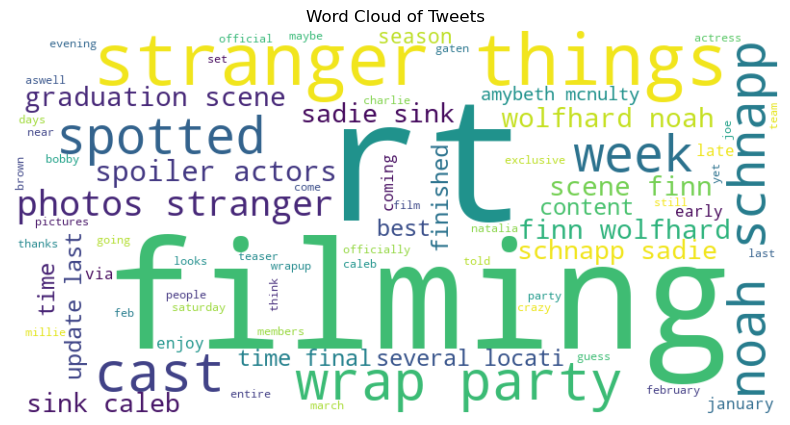

In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(st['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Tweets")
plt.show()


Dari hasil wordcloud, lumayan banyak kata-kata yang sering muncul, seperti rt, wrap party, filming dan stranger things. untuk rt sepertinya merupakan retweet dari twitter. Dari tweets ini, bisa dikatakan bahwa fans stranger things menunggu season terbarunya keluar. bisa dilihat dari kata filming, spoiler, photos, spotted dan graduation scene. Pada fans terlihat menunggu season terkahir dari stranger things. Pada wordcloud juga terdapat nama-nama actor yang memainkan stranger things season 5, seperti finn wolfhard, noah schnapp dan sadie sink. Ditemukan juga kata shipper untuk para aktor, seperti sink caleb.<br>
<br>
Setelah data sudah dipreprocess dan lakukan visualisasi wordcloud, mari lakukan analisis sentimen. Sebelum itu, perlu adanya model analisis sentimen.

In [70]:
df = pd.read_csv(r'C:/Users/yippi/Documents/kuliah ali/7_visual data/movie_data.csv')

import re
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

porter = PorterStemmer()
def tokenizer(text):
    return text.split()

def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

def preprocessor(text):
    text = re.sub(r'<[^>]*>', '', text)
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)
    text = re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')
    return text

df['clean_review'] = df['review'].apply(preprocessor)

Dataset akan dibagi menjadi 80% untuk pelatihan dan 20% untuk pengujian. Data akan dibagi menggunakan package `scikit-learn`. Kode untuk proses praproses ada di bawah ini.

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['clean_review'], df['sentiment'], test_size=0.2, random_state=42)

Model analisis sentimen yang akan digunakan adalah metode Term Frequency-Inverse Document Frequency (TF-IDF). Data teks diubah menjadi TF-IDF. TF-IDF adalah metode yang menghitung seberapa relevan suatu kata dalam rangkaian atau korpus terhadap sebuah teks. Relevansi meningkat sebanding dengan jumlah kemunculan kata dalam teks, tetapi dikompensasi oleh frekuensi kata dalam data.

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Transform text data into TF-IDF vectors
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

C:\Users\yippi\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Setelah data sudah diTF-IDF, data akan diprediksi menggunakan regresi logistik.

In [78]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate predictions on the test data
y_pred = lr.predict(X_test_tfidf)

# Evaluate using metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8956
Precision: 0.8821122369446609
Recall: 0.9115988723318567
F1-score: 0.8966131907308378
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      5034
           1       0.88      0.91      0.90      4966

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



Hasil Evaluasi Model :

Akurasi model adalah 89,56%. Model true positive adalah 88,21%. Semua prediksi true positive dalam set uji adalah 91,16%. Skor f1 adalah 0,8966.

In [92]:
# preprocessing data
porter = PorterStemmer()

def tokenizer(text):
    return text.split()

def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

def preprocessor(text):
    text = re.sub(r'<[^>]*>', '', text)
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)
    text = re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')
    return text

# Clean review text
st['clean_review'] = st['text'].apply(preprocessor)

all_data_tfidf = tfidf.transform(st['clean_review'])
all_data_predictions = lr.predict(all_data_tfidf)

# Add predictions to DataFrame
st['predicted_sentiment'] = all_data_predictions
st[['clean_review','predicted_sentiment']]

,clean_review,predicted_sentiment
0,rt tate100t i was told stranger things season ...,1
1,rt updates_sthings more photos from the strang...,0
2,rt updates_sthings more photos from the strang...,0
3,rt updates_sthings week 50 of stranger things ...,1
4,rt updates_sthings spoiler actors who were fil...,0
5,rt sthingsspoilers it s time for our final fil...,1
6,rt updates_sthings spoiler actors who were fil...,0
7,rt updates_sthings spoiler actors who were fil...,0
8,rt updates_sthings more photos from the strang...,0
9,rt updates_sthings more photos from the strang...,0


Data stranger things sudah dianalisis sentimen. Selanjutnya mari lihat banyaknya sentimen positif dan negatif pada data stranger things

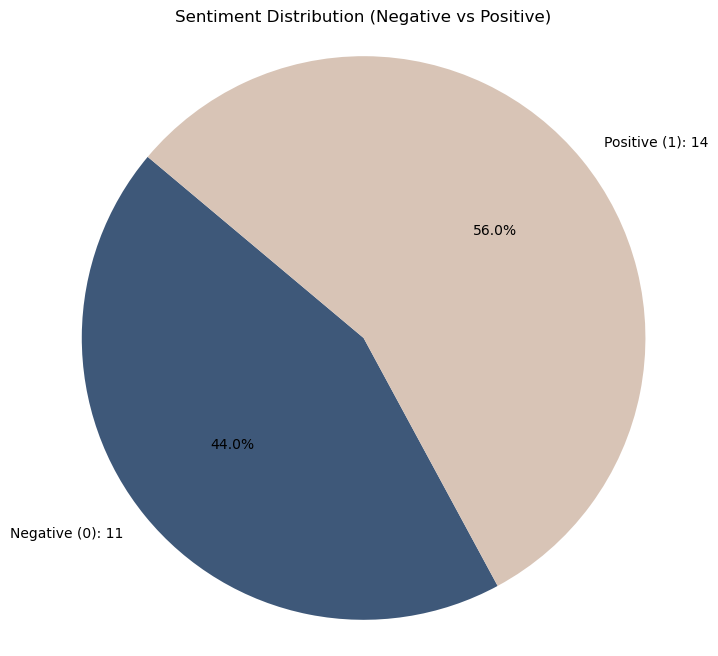

Negative Sentiment: 11
Positive Sentiment: 14


In [103]:
sentiment_counts = st['predicted_sentiment'].value_counts()

# Extract counts for positive and negative sentiments
negative_count = sentiment_counts.get(0, 0)
positive_count = sentiment_counts.get(1, 0)

# Define labels and values for the pie chart
labels = [f'Negative (0): {negative_count}', f'Positive (1): {positive_count}']
sizes = [negative_count, positive_count]

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#3E5879', '#D8C4B6'])
plt.title('Sentiment Distribution (Negative vs Positive)')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle
plt.show()

# Print the counts for reference
print(f"Negative Sentiment: {negative_count}")
print(f"Positive Sentiment: {positive_count}")

Sentimen Positif pada series stranger things 5 adalah 14 sentimen (56%), dan sentimen negatif sebanyak 11 sentimen (44%). Sentimen stranger things 5 kebanyakan positif, dari hal ini dapat disimpulkan adalah  sentimen untuk series stranger things sebagian besar positif. 